In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.interpolate import griddata
import pandas as pd
import glob
from sklearn.linear_model import LinearRegression

In [56]:
# Get data file names
filenames = glob.glob("jaws/simulated/4x4/*/pdd.out")

df4x4 = pd.DataFrame()
for filename in filenames:
    df4x4 = df4x4.add(pd.read_csv(filename, sep=r",", usecols=[2,3,4,5],
    names=['iZ','total', 'total^2','entries'], skiprows=4, engine="python"), fill_value=0)
df4x4=df4x4/np.size(filenames)

# Get data file names
filenames = glob.glob("jaws/simulated/10x10/*/pdd.out")

df10x10 = pd.DataFrame()
for filename in filenames:
    df10x10 = df10x10.add(pd.read_csv(filename, sep=r",", usecols=[2,3,4,5],
    names=['iZ','total', 'total^2','entries'], skiprows=4, engine="python"), fill_value=0)
df10x10=df10x10/np.size(filenames)

# Get data file names
filenames = glob.glob("jaws/simulated/40x40/*/pdd.out")

df40x40 = pd.DataFrame()
for filename in filenames:
    df40x40 = df40x40.add(pd.read_csv(filename, sep=r",", usecols=[2,3,4,5],
    names=['iZ','total', 'total^2','entries'], skiprows=4, engine="python"), fill_value=0)
df40x40=df40x40/np.size(filenames)

In [57]:
z_aux, eDep_aux = np.loadtxt('validation/experimental/4x4/pdd',delimiter="\t",usecols =(0, 1),unpack=True)
exp4x4 = interp1d(z_aux, eDep_aux,kind="slinear")
z4x4 = np.linspace(3, 330.0, 325)
z_aux, eDep_aux = np.loadtxt('validation/experimental/10x10/pdd',delimiter="\t",usecols =(0, 1),unpack=True)
exp10x10 = interp1d(z_aux, eDep_aux,kind="slinear")
z10x10 = np.linspace(3, 330.0, 325)
z_aux, eDep_aux = np.loadtxt('validation/experimental/40x40/pdd',delimiter="\t",usecols =(0, 1),unpack=True)
exp40x40 = interp1d(z_aux, eDep_aux,kind="slinear")
z40x40 = np.linspace(3, 330.0, 325)

In [58]:
K0='6MV'
zMax=500 # cm
nBins=125
scale=zMax/nBins
df4x4['iZ']=zMax-(df4x4['iZ'])*scale-2
df10x10['iZ']=zMax-(df10x10['iZ'])*scale-2
df40x40['iZ']=zMax-(df40x40['iZ'])*scale-2
df4x4['total']=df4x4['total']/2.304468E-13
df10x10['total']=df10x10['total']/2.304468E-13
df40x40['total']=df40x40['total']/2.304468E-13

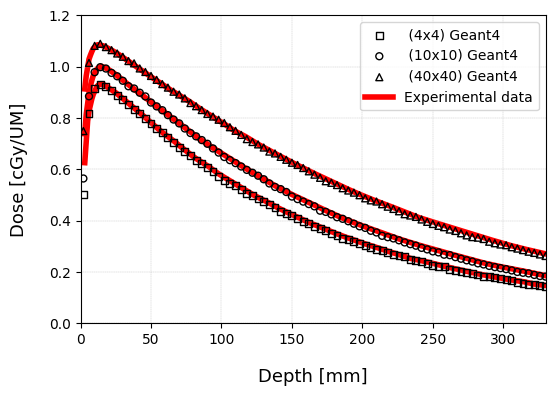

In [59]:
fig=plt.figure(figsize=(6,4))

ax1=fig.add_subplot(111)
ax1.set_xlabel('Depth [mm]', fontsize=13,labelpad=15)
ax1.set_ylabel('Dose [cGy/UM]', fontsize=13,labelpad=15)
ax1.grid(linestyle='--', linewidth=0.25)
ax1.set_xlim(0,330)
ax1.set_ylim(0,1.2)
ax1.scatter(df4x4['iZ'], df4x4['total']*100, s=25, facecolors='none', edgecolors='black', label=" (4x4) Geant4",zorder=5,marker='s')
ax1.scatter(df10x10['iZ'], df10x10['total']*100, s=25, facecolors='none', edgecolors='black', label=" (10x10) Geant4",zorder=5)
ax1.scatter(df40x40['iZ'], df40x40['total']*100, s=25, facecolors='none', edgecolors='black', label=" (40x40) Geant4",zorder=5,marker='^')
ax1.plot(z4x4, exp4x4(z4x4), linestyle="-", linewidth=4, color="red", ms=5,zorder=1)
ax1.plot(z10x10, exp10x10(z10x10), linestyle="-", linewidth=4, color="red", ms=5,zorder=2,label="Experimental data")
ax1.plot(z40x40, exp40x40(z40x40), linestyle="-", linewidth=4, color="red", ms=5,zorder=1)


ax1.legend(loc='best')


In [60]:
iZ=df10x10['iZ']
filter = (iZ >= np.min(z10x10)) & (iZ <= np.max(z10x10))

In [61]:
iZ = iZ[filter]
diff4x4=((exp4x4(iZ))-(df4x4['total'][filter]*100))
diff10x10=((exp10x10(iZ))-(df10x10['total'][filter]*100))
diff40x40=((exp40x40(iZ))-(df40x40['total'][filter]*100))

In [62]:
diffAll=np.append(diff4x4,diff10x10)
diffAll=np.append(diffAll,diff40x40)
iZAll=np.append(iZ,iZ)
iZAll=np.append(iZAll,iZ)

In [63]:
reg = LinearRegression().fit(iZAll.reshape(-1, 1), diffAll)

# Optionally, check coefficients
print(f"Coefficients: {reg.coef_}")
print(f"Intercept: {reg.intercept_}")

Coefficients: [1.8622692e-05]
Intercept: 0.0011850152280476313


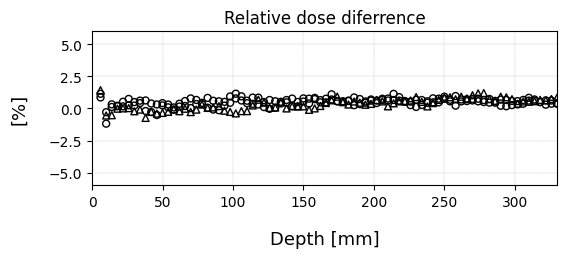

In [64]:
fig=plt.figure(figsize=(6,2))

ax1=fig.add_subplot(111)
ax1.set_xlabel('Depth [mm]', fontsize=13,labelpad=15)
ax1.set_ylabel('[%]', fontsize=13,labelpad=15)
ax1.set_title('Relative dose diferrence')
ax1.grid(linestyle='--', linewidth=0.25)
ax1.set_xlim(0,330)
ax1.set_ylim(-6,6)
ax1.scatter(iZ, diff4x4*100, s=25, facecolors='none', edgecolors='black', label=" (10x10) Geant4",zorder=4)
ax1.scatter(iZ, diff10x10*100, s=25, facecolors='none', edgecolors='black', label=" (10x10) Geant4",zorder=4)
ax1.scatter(iZ, diff40x40*100, s=25, facecolors='none', edgecolors='black', label=" (40x40) Geant4",zorder=4,marker='^')
#plt.plot(iZAll.reshape(-1, 1), reg.predict(iZAll.reshape(-1, 1))*100, color='blue',linewidth=4)
#ax1.legend(loc='best')


(array([ 1.,  2., 11., 35., 85., 64., 39.,  7.,  1.,  1.]),
 array([-0.01297425, -0.01035393, -0.00773361, -0.00511329, -0.00249297,
         0.00012734,  0.00274766,  0.00536798,  0.0079883 ,  0.01060862,
         0.01322893]),
 <BarContainer object of 10 artists>)

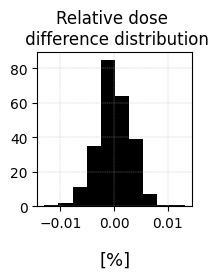

In [65]:
fig=plt.figure(figsize=(2,2))

ax1=fig.add_subplot(111)
ax1.set_xlabel('[%]', fontsize=13,labelpad=15)
ax1.set_title('Relative dose \n difference distribution')
ax1.grid(linestyle='--', linewidth=0.25)
#ax1.set_xlim(0,330)
#ax1.set_ylim(-0.1,0.1)
plt.hist(reg.predict(iZAll.reshape(-1, 1))-diffAll, color='black')
#ax1.legend(loc='best')



In [66]:
print(np.mean(diffAll))
print(np.std(diffAll))

0.0043136274766917785
0.003708203831988364


In [67]:
# Get data file names
filenames = glob.glob("jaws/simulated/10x10/*/pddBuildup.out")

df10x10 = pd.DataFrame()
for filename in filenames:
    df10x10 = df10x10.add(pd.read_csv(filename, sep=r",", usecols=[2,3,4,5],
    names=['iZ','total', 'total^2','entries'], skiprows=4, engine="python"), fill_value=0)
df10x10=df10x10/np.size(filenames)

In [68]:
K0='6MV'
zMax=12 # cm
nBins=12
scale=zMax/nBins
df10x10['iZ']=zMax-(df10x10['iZ'])*scale-2
df10x10['total']=df10x10['total']/2.304468E-13

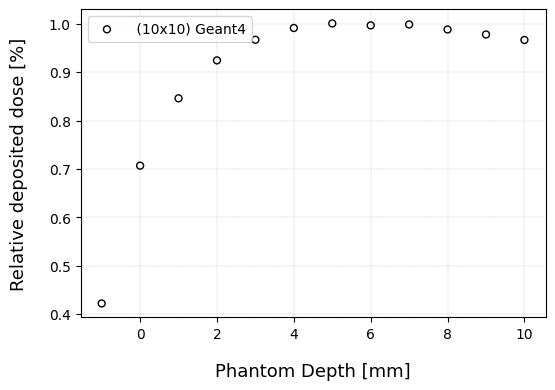

In [69]:
fig=plt.figure(figsize=(6,4))
#fig.suptitle("title", fontsize=16)

ax1=fig.add_subplot(111)
ax1.set_xlabel('Phantom Depth [mm]', fontsize=13,labelpad=15)
ax1.set_ylabel('Relative deposited dose [%]', fontsize=13,labelpad=15)
ax1.grid(linestyle='--', linewidth=0.25)

ax1.scatter(df10x10['iZ'], df10x10['total']*100, s=25, facecolors='none', edgecolors='black', label=" (10x10) Geant4",zorder=4)


ax1.legend(loc='best')

In [70]:
# Get data file names
filenames = glob.glob("jaws/simulated/4x4/*/latProfile_x.out")

df4x4 = pd.DataFrame()
for filename in filenames:
    df4x4 = df4x4.add(pd.read_csv(filename, sep=r",", usecols=[0,3,4,5],
    names=['iX','total', 'total^2','entries'], skiprows=4, engine="python"), fill_value=0)
df4x4=df4x4/np.size(filenames)

# Get data file names
filenames = glob.glob("jaws/simulated/10x10/*/latProfile_x.out")

df10x10 = pd.DataFrame()
for filename in filenames:
    df10x10 = df10x10.add(pd.read_csv(filename, sep=r",", usecols=[0,3,4,5],
    names=['iX','total', 'total^2','entries'], skiprows=4, engine="python"), fill_value=0)
df10x10=df10x10/np.size(filenames)

# Get data file names
filenames = glob.glob("jaws/simulated/40x40/*/latProfile_x.out")

df40x40 = pd.DataFrame()
for filename in filenames:
    df40x40 = df40x40.add(pd.read_csv(filename, sep=r",", usecols=[0,3,4,5],
    names=['iX','total', 'total^2','entries'], skiprows=4, engine="python"), fill_value=0)
df40x40=df40x40/np.size(filenames)

In [71]:
x_aux, eDep_aux = np.loadtxt('validation/experimental/4x4/latProfile_x',delimiter="\t",usecols =(0, 1),unpack=True)
expLat4x4 = interp1d(x_aux, eDep_aux,kind="slinear")
x4x4 = np.linspace(-50, 50.0, 50)
filter = (x_aux>0) & (eDep_aux >= 0.1) & (eDep_aux <= 0.9)
expLat4x4_inv = interp1d(eDep_aux[filter],x_aux[filter],kind="slinear")
x_aux, eDep_aux = np.loadtxt('validation/experimental/10x10/latProfile_x',delimiter="\t",usecols =(0, 1),unpack=True)
expLat10x10 = interp1d(x_aux, eDep_aux,kind="slinear")
x10x10 = np.linspace(-100, 100.0, 100)
filter = (x_aux>0) & (eDep_aux >= 0.1) & (eDep_aux <= 0.9)
expLat10x10_inv = interp1d(eDep_aux[filter],x_aux[filter],kind="slinear")
x_aux, eDep_aux = np.loadtxt('validation/experimental/40x40/latProfile_x',delimiter="\t",usecols =(0, 1),unpack=True)
expLat40x40 = interp1d(x_aux, eDep_aux,kind="slinear")
x40x40 = np.linspace(-250, 250.0, 250)
filter = (x_aux>0) & (eDep_aux >= 0.1) & (eDep_aux <= 0.9)
expLat40x40_inv = interp1d(eDep_aux[filter],x_aux[filter],kind="slinear")

In [72]:
K0='6MV'
xMax=500 # cm
nBins=125
scale=xMax/nBins
df4x4['iX']=xMax-(df4x4['iX'])*scale-252
df10x10['iX']=xMax-(df10x10['iX'])*scale-252
df40x40['iX']=xMax-(df40x40['iX'])*scale-252
df4x4['total']=df4x4['total']/2.304468E-13
df10x10['total']=df10x10['total']/2.304468E-13
df40x40['total']=df40x40['total']/2.304468E-13

In [73]:
sim4x4_latx = interp1d(df4x4['iX'],df4x4['total'],fill_value="extrapolate",kind="slinear")
xSim4x4 = np.linspace(-250, 250.0, 250)

sim10x10_latx = interp1d(df10x10['iX'],df10x10['total'],fill_value="extrapolate",kind="slinear")
xSim10x10 = np.linspace(-250, 250.0, 250)

sim40x40_latx = interp1d(df40x40['iX'],df40x40['total'],fill_value="extrapolate",kind="slinear")
xSim40x40 = np.linspace(-250, 250.0, 250)

In [74]:
sim4x4_inv = interp1d(df4x4['total'][0:62],df4x4['iX'][0:62],fill_value="extrapolate",kind="slinear")
sim10x10_inv = interp1d(df10x10['total'][0:62],df10x10['iX'][0:62],fill_value="extrapolate",kind="slinear")
sim40x40_inv = interp1d(df40x40['total'][0:62],df40x40['iX'][0:62],fill_value="extrapolate",kind="slinear")

In [75]:
print(sim4x4_inv(expLat4x4(0)/2/100), expLat4x4_inv(expLat4x4(0)/2), expLat4x4_inv(expLat4x4(0)/2)/sim4x4_inv(expLat4x4(0)/2/100))
print(sim10x10_inv(expLat10x10(0)/2/100), expLat10x10_inv(expLat10x10(0)/2), expLat10x10_inv(expLat10x10(0)/2)/sim10x10_inv(expLat10x10(0)/2/100) )
print(sim40x40_inv(expLat40x40(0)/2/100), expLat40x40_inv(expLat40x40(0)/2), expLat40x40_inv(expLat40x40(0)/2)/sim40x40_inv(expLat40x40(0)/2/100) )

17.29194266920682 19.811984414814997 1.1457350277997291
42.71093882429446 51.2795087965342 1.2006176920504927
170.8880365134828 205.83941857579612 1.20452796331097


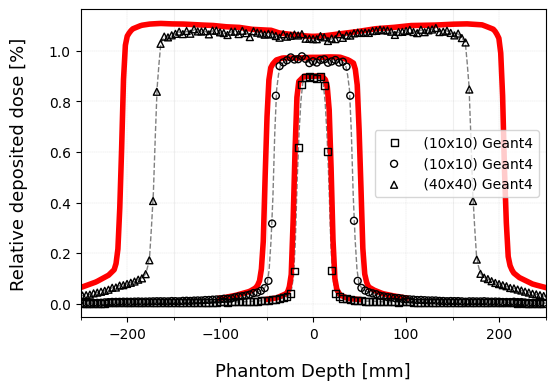

In [76]:
fig=plt.figure(figsize=(6,4))
#fig.suptitle("title", fontsize=16)

ax1=fig.add_subplot(111)
ax1.set_xlabel('Phantom Depth [mm]', fontsize=13,labelpad=15)
ax1.set_ylabel('Relative deposited dose [%]', fontsize=13,labelpad=15)
# Major ticks every 20, minor ticks every 5
major_ticks = np.arange(-400, 400, 100)
minor_ticks = np.arange(-350, 350, 50)

ax1.set_xticks(major_ticks)
ax1.set_xticks(minor_ticks, minor=True)
ax1.grid(linestyle='--', linewidth=0.25)
# Or if you want different settings for the grids:
ax1.grid(which='minor', alpha=0.2)
ax1.grid(which='major', alpha=0.5)
#
ax1.set_xlim(-250,250)
#ax1.set_ylim(0,1.2)
ax1.scatter(df4x4['iX'], df4x4['total']*100, s=25, facecolors='none', edgecolors='black', label=" (10x10) Geant4",zorder=5, marker='s')
ax1.scatter(df10x10['iX'], df10x10['total']*100, s=25, facecolors='none', edgecolors='black', label=" (10x10) Geant4",zorder=5)
ax1.scatter(df40x40['iX'], df40x40['total']*100, s=25, facecolors='none', edgecolors='black', label=" (40x40) Geant4",zorder=5, marker='^')
ax1.plot(xSim4x4, sim4x4_latx(xSim4x4)*100, linestyle="--", linewidth=1, color="gray", ms=5,zorder=2)
ax1.plot(xSim10x10, sim10x10_latx(xSim10x10)*100, linestyle="--", linewidth=1, color="gray", ms=5,zorder=2)
ax1.plot(xSim40x40, sim40x40_latx(xSim40x40)*100, linestyle="--", linewidth=1, color="gray", ms=5,zorder=2)
ax1.plot(x4x4, expLat4x4(x4x4), linestyle="-", linewidth=4, color="red", ms=5,zorder=2)
ax1.plot(x10x10, expLat10x10(x10x10), linestyle="-", linewidth=4, color="red", ms=5,zorder=2)
ax1.plot(x40x40, expLat40x40(x40x40), linestyle="-", linewidth=4, color="red", ms=5,zorder=2)

ax1.legend(loc='best')

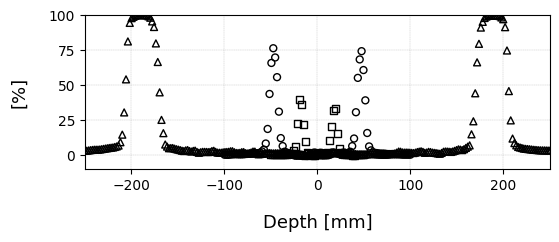

In [77]:
fig=plt.figure(figsize=(6,2))

ax1=fig.add_subplot(111)
ax1.set_xlabel('Depth [mm]', fontsize=13,labelpad=15)
ax1.set_ylabel('[%]', fontsize=13,labelpad=15)
ax1.grid(linestyle='--', linewidth=0.25)
ax1.set_xlim(-250,250)
ax1.set_ylim(-10,100)

ax1.scatter(x4x4, ((expLat4x4(x4x4))-(sim4x4_latx(x4x4)*100))*100, s=25, facecolors='none', edgecolors='black', label=" (4x4) Geant4",zorder=4,marker='s')
ax1.scatter(x10x10, ((expLat10x10(x10x10))-(sim10x10_latx(x10x10)*100))*100, s=25, facecolors='none', edgecolors='black', label=" (10x10) Geant4",zorder=4)
ax1.scatter(x40x40, ((expLat40x40(x40x40))-(sim40x40_latx(x40x40)*100))*100, s=25, facecolors='none', edgecolors='black', label=" (10x10) Geant4",zorder=4,marker='^')
#ax1.legend(loc='best')


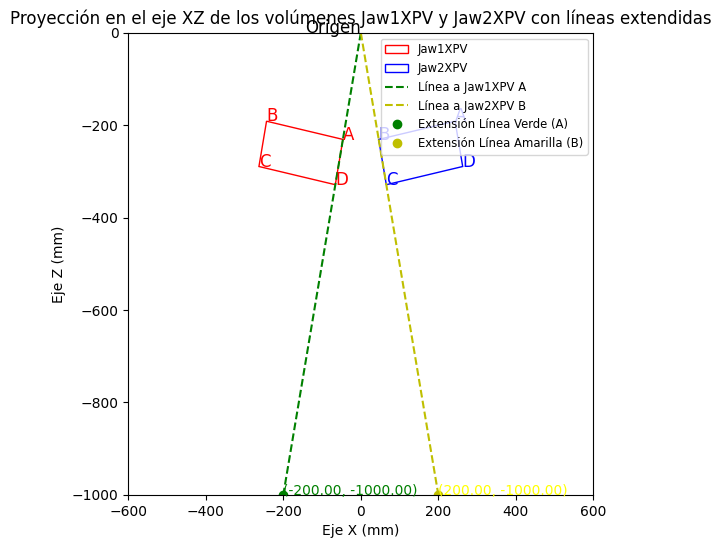

Posición de Jaw1X: [-154.53951449    0.         -260.24611133]
Ángulo de rotación de Jaw1X (radianes): 0.19739555984988078
Ángulo de rotación de Jaw1X (grados): 11.309932474020215
Posición de Jaw2X: [ 154.53951449    0.         -260.24611133]
Ángulo de rotación de Jaw2X (radianes): 0.19739555984988078
Ángulo de rotación de Jaw2X (grados): 11.309932474020215


In [78]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Valores extraídos del archivo
boxSide = 201  # mm (ajustar con el valor extraído del archivo)
fJaw1XAperture = 200  # mm (ajustar con el valor extraído del archivo)
fJaw2XAperture = 200  # mm (ajustar con el valor extraído del archivo)

# Dimensiones de los rectángulos (boxJaw1X y boxJaw2X) en el eje xz
width = boxSide  # mm
height = 100  # mm (dimensión en z)

# Datos iniciales
fReferenceDistance = 100 * 10  # cm (convertido a mm)

# Posiciones iniciales
fJaw1XInitialPos = np.array([width / 2, 0, 235.5 + height / 2])
fJaw2XInitialPos = np.array([-width / 2, 0, 235.5 + height / 2])

# Rotaciones
angleJaw1X = np.abs(np.arctan(fJaw1XAperture / (-(fReferenceDistance))))
angleJaw2X = np.abs(np.arctan(fJaw2XAperture / (-(fReferenceDistance))))

cRotationJaw1X = np.array([[np.cos(angleJaw1X), 0, np.sin(angleJaw1X)], 
                           [0, 1, 0], 
                           [-np.sin(angleJaw1X), 0, np.cos(angleJaw1X)]])
cRotationJaw2X = np.array([[np.cos(-angleJaw2X), 0, np.sin(-angleJaw2X)], 
                           [0, 1, 0], 
                           [-np.sin(-angleJaw2X), 0, np.cos(-angleJaw2X)]])

# Aplicar rotación a las posiciones
position1_rotated = np.dot(cRotationJaw1X, -fJaw1XInitialPos)
position2_rotated = np.dot(cRotationJaw2X, -fJaw2XInitialPos)

# Función para rotar las esquinas del rectángulo
def rotate_corners(rotation, width, height):
    # Esquinas del rectángulo sin rotar
    corners = np.array([
        [width / 2, 0, height / 2],
        [-width / 2, 0, height / 2],
        [-width / 2, 0, -height / 2],
        [width / 2, 0, -height / 2]
    ])
    # Rotar las esquinas
    rotated_corners = np.dot(rotation, corners.T).T
    return rotated_corners

# Función para trasladar las esquinas rotadas
def translate_corners(rotated_corners, position):
    return rotated_corners + position

# Rotar las esquinas
corners1_rotated = rotate_corners(cRotationJaw1X, width, height)
corners2_rotated = rotate_corners(cRotationJaw2X, width, height)

# Trasladar las esquinas rotadas
corners1 = translate_corners(corners1_rotated, position1_rotated)
corners2 = translate_corners(corners2_rotated, position2_rotated)

# Seleccionar solo las coordenadas x y z para la visualización
corners1 = corners1[:, [0, 2]]
corners2 = corners2[:, [0, 2]]

# Nombres de los vértices
vertex_names = ['A', 'B', 'C', 'D']

# Obtener las coordenadas de los vértices
corners1_named = {name: coord for name, coord in zip(vertex_names, corners1)}
corners2_named = {name: coord for name, coord in zip(vertex_names, corners2)}

# Coordenadas de los puntos A y B
point_A1 = corners1_named['A']
point_B2 = corners2_named['B']

# origen
origin = np.array([0, 0])

# Crear las líneas que pasan por los puntos A y B y también por el nuevo origen
def extend_line_through_point(p, origin, z=-1000):
    slope = (p[1] - origin[1]) / (p[0] - origin[0]) if p[0] != origin[0] else 0
    x_ext = p[0] + (z - p[1]) / slope if slope != 0 else p[0]
    return [x_ext, z]

extended_point_A1 = extend_line_through_point(point_A1, origin, -1000)
extended_point_B2 = extend_line_through_point(point_B2, origin, -1000)

# Crear figura y ejes con mayor resolución
fig, ax = plt.subplots(figsize=(6, 6), dpi=100)

# Crear los dos rectángulos rotados
rect1 = patches.Polygon(corners1, closed=True, linewidth=1, edgecolor='r', facecolor='none', label='Jaw1XPV')
rect2 = patches.Polygon(corners2, closed=True, linewidth=1, edgecolor='b', facecolor='none', label='Jaw2XPV')

# Añadir los rectángulos a los ejes
ax.add_patch(rect1)
ax.add_patch(rect2)

# Trazar las líneas extendidas desde el nuevo origen pasando por los puntos A y B y hasta z=-1000
ax.plot([origin[0], point_A1[0]], [origin[1], point_A1[1]], 'g--', label='Línea a Jaw1XPV A')
ax.plot([origin[0], point_B2[0]], [origin[1], point_B2[1]], 'y--', label='Línea a Jaw2XPV B')
ax.plot([point_A1[0], extended_point_A1[0]], [point_A1[1], extended_point_A1[1]], 'g--')
ax.plot([point_B2[0], extended_point_B2[0]], [point_B2[1], extended_point_B2[1]], 'y--')

# Añadir markers en las coordenadas extendidas con tamaño menor
ax.plot(extended_point_A1[0], extended_point_A1[1], 'go', markersize=6, label='Extensión Línea Verde (A)')
ax.plot(extended_point_B2[0], extended_point_B2[1], 'yo', markersize=6, label='Extensión Línea Amarilla (B)')

# Añadir etiquetas de los vértices y el nuevo origen
for name, coord in corners1_named.items():
    ax.text(coord[0], coord[1], f'{name}', color='red', fontsize=12)
for name, coord in corners2_named.items():
    ax.text(coord[0], coord[1], f'{name}', color='blue', fontsize=12)
ax.text(origin[0], origin[1], 'Origen', color='black', fontsize=12, ha='right')

# Mostrar las coordenadas x de los markers
ax.text(extended_point_A1[0], extended_point_A1[1], f'({extended_point_A1[0]:.2f}, {extended_point_A1[1]:.2f})', color='green', fontsize=10)
ax.text(extended_point_B2[0], extended_point_B2[1], f'({extended_point_B2[0]:.2f}, {extended_point_B2[1]:.2f})', color='yellow', fontsize=10)

# Establecer los límites de los ejes para incluir los rectángulos y las líneas extendidas
ax.set_xlim(-600, 600)
ax.set_ylim(-1000, 0)

# Añadir etiquetas y título
ax.set_xlabel('Eje X (mm)')
ax.set_ylabel('Eje Z (mm)')
ax.set_title('Proyección en el eje XZ de los volúmenes Jaw1XPV y Jaw2XPV con líneas extendidas')
ax.legend(fontsize='small', loc='upper right')

# Mostrar la gráfica
plt.show()

# Imprimir posiciones y ángulos de rotación
print(f"Posición de Jaw1X: {position1_rotated}")
print(f"Ángulo de rotación de Jaw1X (radianes): {angleJaw1X}")
print(f"Ángulo de rotación de Jaw1X (grados): {np.degrees(angleJaw1X)}")

print(f"Posición de Jaw2X: {position2_rotated}")
print(f"Ángulo de rotación de Jaw2X (radianes): {angleJaw2X}")
print(f"Ángulo de rotación de Jaw2X (grados): {np.degrees(angleJaw2X)}")

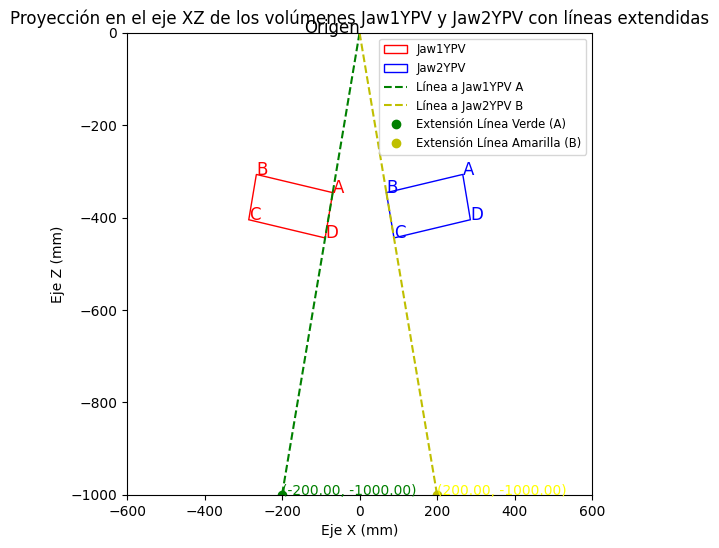

Posición de Jaw1Y: [-177.58316037    0.         -375.46434072]
Ángulo de rotación de Jaw1Y (radianes): 0.19739555984988078
Ángulo de rotación de Jaw1Y (grados): 11.309932474020215
Posición de Jaw2Y: [ 177.58316037    0.         -375.46434072]
Ángulo de rotación de Jaw2Y (radianes): 0.19739555984988078
Ángulo de rotación de Jaw2Y (grados): 11.309932474020215


In [79]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Valores extraídos del archivo
boxSide = 201  # mm (ajustar con el valor extraído del archivo)
fJaw1YAperture = 200  # mm (ajustar con el valor extraído del archivo)
fJaw2YAperture = 200  # mm (ajustar con el valor extraído del archivo)

# Dimensiones de los rectángulos (boxJaw1Y y boxJaw2Y) en el eje yz
width = boxSide  # mm
height = 100  # mm (dimensión en z)

# Datos iniciales
fReferenceDistance = 100 * 10  # cm (convertido a mm)

# Posiciones iniciales
fJaw1YInitialPos = np.array([width / 2, 0, 235.5 + 117.5 + height / 2])
fJaw2YInitialPos = np.array([-width / 2, 0, 235.5 + 117.5 + height / 2])

# Rotaciones
angleJaw1Y = np.abs(np.arctan(fJaw1YAperture / (-(fReferenceDistance))))
angleJaw2Y = np.abs(np.arctan(fJaw2YAperture / (-(fReferenceDistance))))

cRotationJaw1Y = np.array([[np.cos(angleJaw1Y), 0, np.sin(angleJaw1Y)], 
                           [0, 1, 0], 
                           [-np.sin(angleJaw1Y), 0, np.cos(angleJaw1Y)]])
cRotationJaw2Y = np.array([[np.cos(-angleJaw2Y), 0, np.sin(-angleJaw2Y)], 
                           [0, 1, 0], 
                           [-np.sin(-angleJaw2Y), 0, np.cos(-angleJaw2Y)]])

# Aplicar rotación a las posiciones
position1_rotated = np.dot(cRotationJaw1Y, -fJaw1YInitialPos)
position2_rotated = np.dot(cRotationJaw2Y, -fJaw2YInitialPos)

# Función para rotar las esquinas del rectángulo
def rotate_corners(rotation, width, height):
    # Esquinas del rectángulo sin rotar
    corners = np.array([
        [width / 2, 0, height / 2],
        [-width / 2, 0, height / 2],
        [-width / 2, 0, -height / 2],
        [width / 2, 0, -height / 2]
    ])
    # Rotar las esquinas
    rotated_corners = np.dot(rotation, corners.T).T
    return rotated_corners

# Función para trasladar las esquinas rotadas
def translate_corners(rotated_corners, position):
    return rotated_corners + position

# Rotar las esquinas
corners1_rotated = rotate_corners(cRotationJaw1Y, width, height)
corners2_rotated = rotate_corners(cRotationJaw2Y, width, height)

# Trasladar las esquinas rotadas
corners1 = translate_corners(corners1_rotated, position1_rotated)
corners2 = translate_corners(corners2_rotated, position2_rotated)

# Seleccionar solo las coordenadas x y z para la visualización
corners1 = corners1[:, [0, 2]]
corners2 = corners2[:, [0, 2]]

# Nombres de los vértices
vertex_names = ['A', 'B', 'C', 'D']

# Obtener las coordenadas de los vértices
corners1_named = {name: coord for name, coord in zip(vertex_names, corners1)}
corners2_named = {name: coord for name, coord in zip(vertex_names, corners2)}

# Coordenadas de los puntos A y B
point_A1 = corners1_named['A']
point_B2 = corners2_named['B']

# origen
origin = np.array([0, 0])

# Crear las líneas que pasan por los puntos A y B y también por el nuevo origen
def extend_line_through_point(p, origin, z=-1000):
    slope = (p[1] - origin[1]) / (p[0] - origin[0]) if p[0] != origin[0] else 0
    x_ext = p[0] + (z - p[1]) / slope if slope != 0 else p[0]
    return [x_ext, z]

extended_point_A1 = extend_line_through_point(point_A1, origin, -1000)
extended_point_B2 = extend_line_through_point(point_B2, origin, -1000)

# Crear figura y ejes con mayor resolución
fig, ax = plt.subplots(figsize=(6, 6), dpi=100)

# Crear los dos rectángulos rotados
rect1 = patches.Polygon(corners1, closed=True, linewidth=1, edgecolor='r', facecolor='none', label='Jaw1YPV')
rect2 = patches.Polygon(corners2, closed=True, linewidth=1, edgecolor='b', facecolor='none', label='Jaw2YPV')

# Añadir los rectángulos a los ejes
ax.add_patch(rect1)
ax.add_patch(rect2)

# Trazar las líneas extendidas desde el nuevo origen pasando por los puntos A y B y hasta z=-1000
ax.plot([origin[0], point_A1[0]], [origin[1], point_A1[1]], 'g--', label='Línea a Jaw1YPV A')
ax.plot([origin[0], point_B2[0]], [origin[1], point_B2[1]], 'y--', label='Línea a Jaw2YPV B')
ax.plot([point_A1[0], extended_point_A1[0]], [point_A1[1], extended_point_A1[1]], 'g--')
ax.plot([point_B2[0], extended_point_B2[0]], [point_B2[1], extended_point_B2[1]], 'y--')

# Añadir markers en las coordenadas extendidas con tamaño menor
ax.plot(extended_point_A1[0], extended_point_A1[1], 'go', markersize=6, label='Extensión Línea Verde (A)')
ax.plot(extended_point_B2[0], extended_point_B2[1], 'yo', markersize=6, label='Extensión Línea Amarilla (B)')

# Añadir etiquetas de los vértices y el nuevo origen
for name, coord in corners1_named.items():
    ax.text(coord[0], coord[1], f'{name}', color='red', fontsize=12)
for name, coord in corners2_named.items():
    ax.text(coord[0], coord[1], f'{name}', color='blue', fontsize=12)
ax.text(origin[0], origin[1], 'Origen', color='black', fontsize=12, ha='right')

# Mostrar las coordenadas x de los markers
ax.text(extended_point_A1[0], extended_point_A1[1], f'({extended_point_A1[0]:.2f}, {extended_point_A1[1]:.2f})', color='green', fontsize=10)
ax.text(extended_point_B2[0], extended_point_B2[1], f'({extended_point_B2[0]:.2f}, {extended_point_B2[1]:.2f})', color='yellow', fontsize=10)

# Establecer los límites de los ejes para incluir los rectángulos y las líneas extendidas
ax.set_xlim(-600, 600)
ax.set_ylim(-1000, 0)

# Añadir etiquetas y título
ax.set_xlabel('Eje X (mm)')
ax.set_ylabel('Eje Z (mm)')
ax.set_title('Proyección en el eje XZ de los volúmenes Jaw1YPV y Jaw2YPV con líneas extendidas')
ax.legend(fontsize='small', loc='upper right')

# Mostrar la gráfica
plt.show()

# Imprimir posiciones y ángulos de rotación
print(f"Posición de Jaw1Y: {position1_rotated}")
print(f"Ángulo de rotación de Jaw1Y (radianes): {angleJaw1Y}")
print(f"Ángulo de rotación de Jaw1Y (grados): {np.degrees(angleJaw1Y)}")

print(f"Posición de Jaw2Y: {position2_rotated}")
print(f"Ángulo de rotación de Jaw2Y (radianes): {angleJaw2Y}")
print(f"Ángulo de rotación de Jaw2Y (grados): {np.degrees(angleJaw2Y)}")
